In [6]:
import stim
import pymatching
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [7]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors


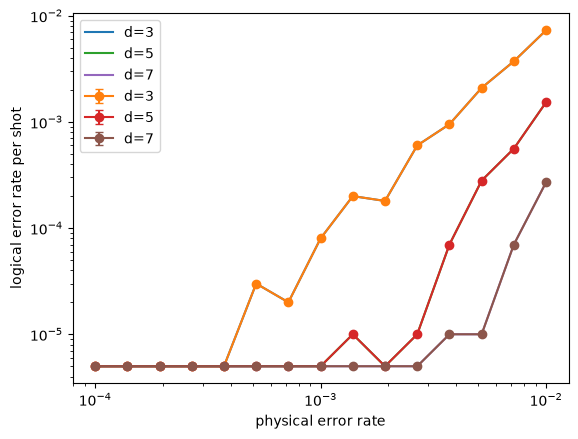

In [12]:
num_shots = 100000
for d in [3, 5, 7]:
    xs = []
    ys = []
    errs = []
    for noise in np.logspace(-4, -2, 15):
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
            )
        num_errors_sampled = count_logical_errors(circuit,num_shots)
        pL= max(0.5,num_errors_sampled) / num_shots
        err = pL * (1 - pL) / num_shots
        xs.append(noise)
        ys.append(pL)
        errs.append(err)
    plt.plot(xs, ys, label="d=" + str(d))
    plt.errorbar(xs, ys, yerr=errs, marker="o", capsize=3, label=f"d={d}")
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()

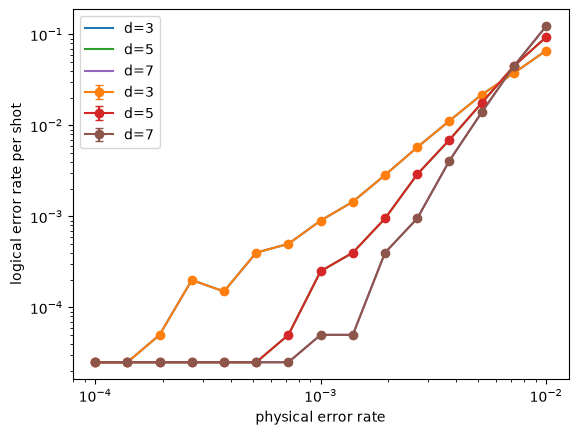

In [13]:
num_shots = 20000
for d in [3, 5, 7]:
    xs = []
    ys = []
    errs = []
    for noise in np.logspace(-4, -2, 15):
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
            )
        num_errors_sampled = count_logical_errors(circuit,num_shots)
        pL= max(0.5,num_errors_sampled) / num_shots
        err = pL * (1 - pL) / num_shots
        xs.append(noise)
        ys.append(pL)
        errs.append(err)
    plt.plot(xs, ys, label="d=" + str(d))
    plt.errorbar(xs, ys, yerr=errs, marker="o", capsize=3, label=f"d={d}")
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()

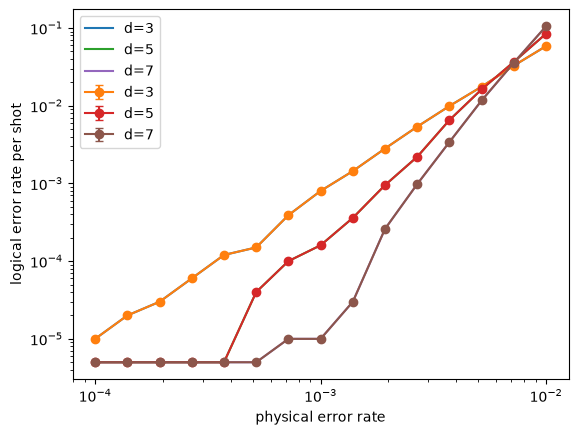

In [14]:
num_shots = 100000
for d in [3, 5, 7]:
    xs = []
    ys = []
    errs = []
    for noise in np.logspace(-4, -2, 15):
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=d,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
            )
        num_errors_sampled = count_logical_errors(circuit,num_shots)
        pL= max(0.5,num_errors_sampled) / num_shots
        err = pL * (1 - pL) / num_shots
        xs.append(noise)
        ys.append(pL)
        errs.append(err)
    plt.plot(xs, ys, label="d=" + str(d))
    plt.errorbar(xs, ys, yerr=errs, marker="o", capsize=3, label=f"d={d}")
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()